# Этап 2: Feature Engineering
## 1. Загрузка и первичный осмотр

In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print(train.shape)
print(test.shape)

print(train.head(3))

(891, 12)
(418, 11)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  


## 2. Анализ пропусков
Посмотрим, сколько данных отсутствует в каждой колонке

In [ ]:
print(f"Всего записей: {len(train)}\n")

missing = train.isna().sum()
missing_percent = (missing / len(train)) * 100

missing_df = pd.DataFrame({
    'Пропущено': missing,
    'Процент': missing_percent
})
missing_df = missing_df[missing_df['Пропущено'] > 0].sort_values('Пропущено', ascending=False)
print(missing_df)


Всего записей: 891

          Пропущено    Процент
Cabin           687  77.104377
Age             177  19.865320
Embarked          2   0.224467


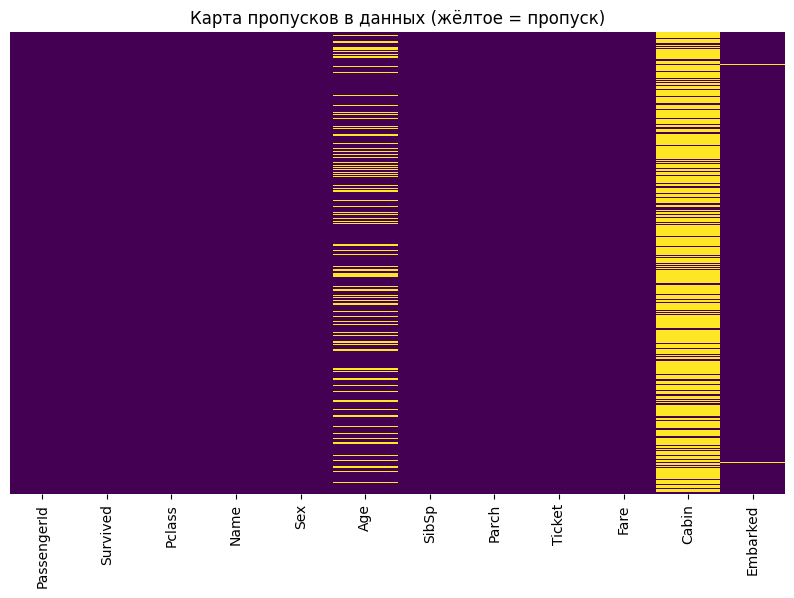

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Строим тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Карта пропусков в данных (жёлтое = пропуск)')
plt.show()

**Выводы:** 
- Cabin пропущена почти полностью (77%) — нужно особое обращение
- Age пропущена у 20% пассажиров — надо заполнять
- Embarked пропущена всего у 2 — заполним самым частым значением


## 3. Обработка пропусков

Что сделать:

- Age
    
    Заполнить пропуски (медиана по группе Pclass + Sex)

    (Медиана — это «средний» элемент в упорядоченном списке)

- Embarked
    
    Заполнить двумя самыми частыми значениями (mode)

- Cabin
    
    Создать новый признак "есть ли каюта" (0/1)

- Fare
    
    В test один пропуск — заполнить медианой по классу

После заполнения проверить, что пропусков не осталось.

In [ ]:
# Считаем медиану возраста для каждой группы
age_medians = train.groupby(['Pclass', 'Sex'])['Age'].median()
print(age_medians)

# Функция, которая для каждой строки возвращает медиану её группы
def fill_age(row):
    if pd.isna(row['Age']):
        return age_medians[row['Pclass'], row['Sex']]
    else:
        return row['Age']

# Сделаем копию датафрейма
train_upd = train.copy()

# Применяем
train_upd['Age'] = train_upd.apply(fill_age, axis=1)


Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


In [ ]:
# Находим самое частое значение
mode_embarked = train['Embarked'].mode()[0]
print(f"Самое частое значение в Embarked: {mode_embarked}")

# Заполняем пропуски
train_upd['Embarked'] = train_upd['Embarked'].fillna(mode_embarked)

Самое частое значение в Embarked: S


In [ ]:
# Сначала HasCabin
train_upd['HasCabin'] = train_upd['Cabin'].notna().astype(int)

# Потом Deck (палуба)
train_upd['Deck'] = train_upd['Cabin'].astype(str).str[0]
train_upd.loc[train_upd['HasCabin'] == 0, 'Deck'] = 'U'  # Unknown для тех, у кого нет каюты

# Проверяем
print(train_upd[['Cabin', 'HasCabin', 'Deck']].head(10))


  Cabin  HasCabin Deck
0   NaN         0    U
1   C85         1    C
2   NaN         0    U
3  C123         1    C
4   NaN         0    U
5   NaN         0    U
6   E46         1    E
7   NaN         0    U
8   NaN         0    U
9   NaN         0    U


In [ ]:
missing = train_upd.isna().sum()
missing_percent = (missing / len(train_upd)) * 100

missing_df = pd.DataFrame({
    'Пропущено': missing,
    'Процент': missing_percent
})
missing_df = missing_df[missing_df['Пропущено'] > 0].sort_values('Пропущено', ascending=False)
print(missing_df)

       Пропущено    Процент
Cabin        687  77.104377


### Сделаем те же преобразования для датасета test

In [ ]:
print(f"Всего записей: {len(test)}\n")

missing = test.isna().sum()
missing_percent = (missing / len(test)) * 100

missing_df = pd.DataFrame({
    'Пропущено': missing,
    'Процент': missing_percent
})
missing_df = missing_df[missing_df['Пропущено'] > 0].sort_values('Пропущено', ascending=False)
print(missing_df)

# Сделаем копию датафрейма
test_upd = test.copy()

# Применяем
test_upd['Age'] = test_upd.apply(fill_age, axis=1)

# медиана Fare по классу
fare_medians = train.groupby('Pclass')['Fare'].median()
print(fare_medians)

# Для строки с пропуском в Fare определяем класс и берём его медиану
def fill_fare(row):
    if pd.isna(row['Fare']):
        return fare_medians[row['Pclass']]
    else:
        return row['Fare']

test_upd['Fare'] = test_upd.apply(fill_fare, axis=1)

# Сначала HasCabin
test_upd['HasCabin'] = test_upd['Cabin'].notna().astype(int)

# Потом Deck (палуба)
test_upd['Deck'] = test_upd['Cabin'].astype(str).str[0]
test_upd.loc[test_upd['HasCabin'] == 0, 'Deck'] = 'U'  # Unknown для тех, у кого нет каюты

# Проверяем
print(test_upd[['Cabin', 'HasCabin', 'Deck']].head(10))

missing = test_upd.isna().sum()
missing_percent = (missing / len(test_upd)) * 100

missing_df = pd.DataFrame({
    'Пропущено': missing,
    'Процент': missing_percent
})
missing_df = missing_df[missing_df['Пропущено'] > 0].sort_values('Пропущено', ascending=False)
print(missing_df)

Всего записей: 418

       Пропущено    Процент
Cabin        327  78.229665
Age           86  20.574163
Fare           1   0.239234
Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64
  Cabin  HasCabin Deck
0   NaN         0    U
1   NaN         0    U
2   NaN         0    U
3   NaN         0    U
4   NaN         0    U
5   NaN         0    U
6   NaN         0    U
7   NaN         0    U
8   NaN         0    U
9   NaN         0    U
       Пропущено    Процент
Cabin        327  78.229665


## 4. Создание новых признаков ##

 - Title (титул) — извлечь из Name (Mr, Mrs, Miss, Master, Rare)

 - FamilySize (размер семьи) = SibSp + Parch + 1

 - IsAlone (одинокий) = 1 если FamilySize == 1, иначе 0

 - Deck (палуба) — первая буква Cabin, если нет — 'U'

 - HasCabin (была ли каюта) — 0/1

 - FarePerPerson — стоимость билета на человека (Fare / FamilySize)

 - AgeGroup — возрастная группа (Child, Teen, Adult, Senior)
 

In [ ]:
print("training dataset")
# извлекаем титул
train_upd['Title'] = train_upd['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# уникальные значения
print(train_upd['Title'].unique())


print("test dataset")
# извлекаем титул
test_upd['Title'] = test_upd['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# уникальные значения
print(test_upd['Title'].unique())


training dataset
<StringArray>
[      'Mr',      'Mrs',     'Miss',   'Master',      'Don',      'Rev',
       'Dr',      'Mme',       'Ms',    'Major',     'Lady',      'Sir',
     'Mlle',      'Col',     'Capt', 'Countess', 'Jonkheer']
Length: 17, dtype: str
test dataset
<StringArray>
['Mr', 'Mrs', 'Miss', 'Master', 'Ms', 'Col', 'Rev', 'Dr', 'Dona']
Length: 9, dtype: str


### Теперь создаём другие признаки:

1. FamilySize (размер семьи)

2. IsAlone (одинокий)

3. FarePerPerson (стоимость на человека)

4. AgeGroup (возрастные группы)

In [ ]:
train_upd['FamilySize'] = train_upd['SibSp'] + train_upd['Parch'] + 1
print('Размер семьи')
print(train_upd['FamilySize'].value_counts().sort_index())

train_upd['IsAlone'] = (train_upd['FamilySize'] == 1).astype(int)
print('Одинокий')
print(train_upd['IsAlone'].value_counts())

train_upd['FarePerPerson'] = train_upd['Fare'] / train_upd['FamilySize']
print('Стоимость на человека')
print(train_upd[['Fare', 'FamilySize', 'FarePerPerson']].head())

# Функция для группировки возраста
def age_group(age):
    if age < 5:
        return 'Infant'
    elif age < 13:
        return 'Child'
    elif age < 18:
        return 'Teen'
    elif age < 35:
        return 'YoungAdult'
    elif age < 55:
        return 'Adult'
    else:
        return 'Senior'

train_upd['AgeGroup'] = train_upd['Age'].apply(age_group)
print('Возрастная группа')
print(train_upd['AgeGroup'].unique())

Размер семьи
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64
Одинокий
IsAlone
1    537
0    354
Name: count, dtype: int64
Стоимость на человека
      Fare  FamilySize  FarePerPerson
0   7.2500           2        3.62500
1  71.2833           2       35.64165
2   7.9250           1        7.92500
3  53.1000           2       26.55000
4   8.0500           1        8.05000
Возрастная группа
<StringArray>
['YoungAdult', 'Adult', 'Infant', 'Teen', 'Senior', 'Child']
Length: 6, dtype: str


In [ ]:
test_upd['FamilySize'] = test_upd['SibSp'] + test_upd['Parch'] + 1
print('Размер семьи')
print(test_upd['FamilySize'].value_counts().sort_index())

test_upd['IsAlone'] = (test_upd['FamilySize'] == 1).astype(int)
print('Одинокий')
print(test_upd['IsAlone'].value_counts())

test_upd['FarePerPerson'] = test_upd['Fare'] / test_upd['FamilySize']
print('Стоимость на человека')
print(test_upd[['Fare', 'FamilySize', 'FarePerPerson']].head())

test_upd['AgeGroup'] = test_upd['Age'].apply(age_group)
print('Возрастная группа')
print(test_upd['AgeGroup'].unique())

Размер семьи
FamilySize
1     253
2      74
3      57
4      14
5       7
6       3
7       4
8       2
11      4
Name: count, dtype: int64
Одинокий
IsAlone
1    253
0    165
Name: count, dtype: int64
Стоимость на человека
      Fare  FamilySize  FarePerPerson
0   7.8292           1       7.829200
1   7.0000           2       3.500000
2   9.6875           1       9.687500
3   8.6625           1       8.662500
4  12.2875           3       4.095833
Возрастная группа
<StringArray>
['YoungAdult', 'Adult', 'Senior', 'Teen', 'Child', 'Infant']
Length: 6, dtype: str


## 5. Преобразуем категориальные признаки в числа

In [ ]:
# Sex: male=0, female=1
train_upd['Sex'] = train_upd['Sex'].map({'male': 0, 'female': 1})
test_upd['Sex'] = test_upd['Sex'].map({'male': 0, 'female': 1})

# One-Hot Encoding для категориальных признаков
train_upd = pd.get_dummies(train_upd, columns=['Embarked', 'Title', 'Deck', 'AgeGroup'], drop_first=True)
test_upd = pd.get_dummies(test_upd, columns=['Embarked', 'Title', 'Deck', 'AgeGroup'], drop_first=True)


## 6. Удаляем ненужные колонки

Name - Не несёт полезной информации (титул уже извлекли)
Ticket - Слишком много уникальных значений
Cabin - Заменили на HasCabin и Deck

In [ ]:
train_upd = train_upd.drop(['Name', 'Ticket', 'Cabin'], axis=1)
test_upd = test_upd.drop(['Name', 'Ticket', 'Cabin'], axis=1)

## 7. Проверяем и сохраняем обработанные данные

In [ ]:
print("Колонки train:", train_upd.shape[1])
print("Колонки test:", test_upd.shape[1])

print("\n...Добавляем, удаляем и приводим к одинаковому порядку колонки...\n")

# 🔧 ВЫРАВНИВАЕМ КОЛОНКИ (без удаления Survived)
train_cols = set(train_upd.columns)
test_cols = set(test_upd.columns)

# Добавляем в test колонки, которые есть в train, но нет в test
for col in (train_cols - test_cols - {'Survived'}):
    test_upd[col] = 0

# Удаляем из test колонки, которых нет в train
cols_to_remove = (test_cols - train_cols)
test_upd = test_upd.drop(columns=cols_to_remove, errors='ignore')

# Приводим к одинаковому порядку колонок
test_cols_ordered = [col for col in train_upd.columns if col in test_upd.columns]
test_upd = test_upd[test_cols_ordered]

# Проверяем
print("Колонки train:", train_upd.shape[1])
print("Колонки test:", test_upd.shape[1])
print(f"Общие колонки: {len(set(train_upd.columns) & set(test_upd.columns))}")

# Сохраняем
print("\nСохраняем обработанные данные")
train_upd.to_csv('../data/train_processed.csv', index=False)
test_upd.to_csv('../data/test_processed.csv', index=False)
print("Данные сохранены!")


Колонки train: 43
Колонки test: 33

...Добавляем, удаляем и приводим к одинаковому порядку колонки...

Колонки train: 43
Колонки test: 42
Общие колонки: 42

Сохраняем обработанные данные
Данные сохранены!
